# 04 — Explainability & Recommendations
## EV Charger Reliability Analytics

This notebook uses SHAP (SHapley Additive exPlanations) values to interpret the model's predictions. We analyze the feature contributions for the **Non-Operational Class** (with proper target alignment where positive SHAP values increase Operational likelihood and negative SHAP values increase Non-Operational likelihood).

We specifically scrutinize the `operator_id` feature, compare SHAP importances before and after excluding the `operator_id == -1` missing data bucket, and address our core business questions.


## 1. Imports & Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path().resolve().parent))

# Plot styling
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

ROOT = Path().resolve().parent
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"

# Load the features without country for geography-blind explainability
X_full = pd.read_csv(PROC / "features_without_country.csv")
y = pd.read_csv(PROC / "target.csv").squeeze()

# Drop country_id to ensure complete geography-blindness
X_full = X_full.drop(columns=["country_id"], errors="ignore")

print(f"Loaded X_full: {X_full.shape} | y: {y.shape}")


Loaded X_full: (10330, 17) | y: (10330,)


/Users/kireeti/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. SHAP Run 1: Full Dataset (Including operator_id == -1)

First, we train a Random Forest on the entire dataset and look at feature importance. The target is encoded as:
- `y = 1`: Operational
- `y = 0`: Non-Operational

*Interpretation note:* In the plots below, negative SHAP values (points to the left of 0.0) indicate factors driving a station toward **Non-Operational status (Failure risk)**. Positive SHAP values (right of 0.0) drive it toward **Operational status**.


<Figure size 1300x780 with 0 Axes>

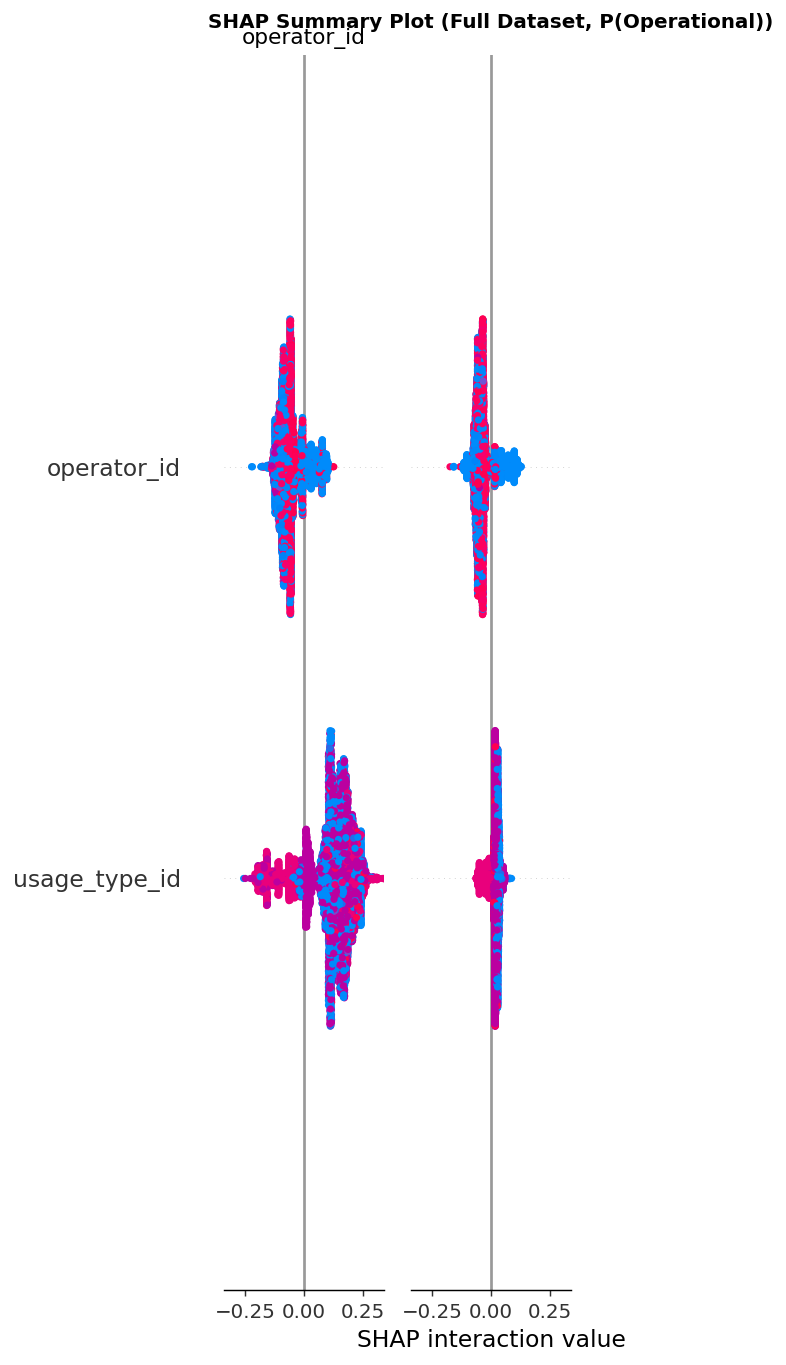

In [2]:
rf_full = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_full.fit(X_full, y)

explainer_full = shap.TreeExplainer(rf_full)
shap_values_full = explainer_full.shap_values(X_full)

# RF returns a list: index 0 is class 0 (Non-Operational), index 1 is class 1 (Operational).
# We plot class 1 (Operational) to follow standard binary convention, or class 0 directly.
# Let's plot class 1 (Operational) - thus, negative SHAP = failure risk.
shap_vals_class1_full = shap_values_full[1] if isinstance(shap_values_full, list) else shap_values_full

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1_full, X_full, show=False, max_display=12)
plt.title("SHAP Summary Plot (Full Dataset, P(Operational))", fontsize=11, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_shap_full.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. SHAP Run 2: Excluding operator_id == -1

Now, we repeat the process by excluding stations that have missing operator IDs (`operator_id == -1`), which we discovered is a heavy geography proxy for South African reporting gaps.


Filtered dataset size: (9082, 17) (Excluded 1248 rows)


<Figure size 1300x780 with 0 Axes>

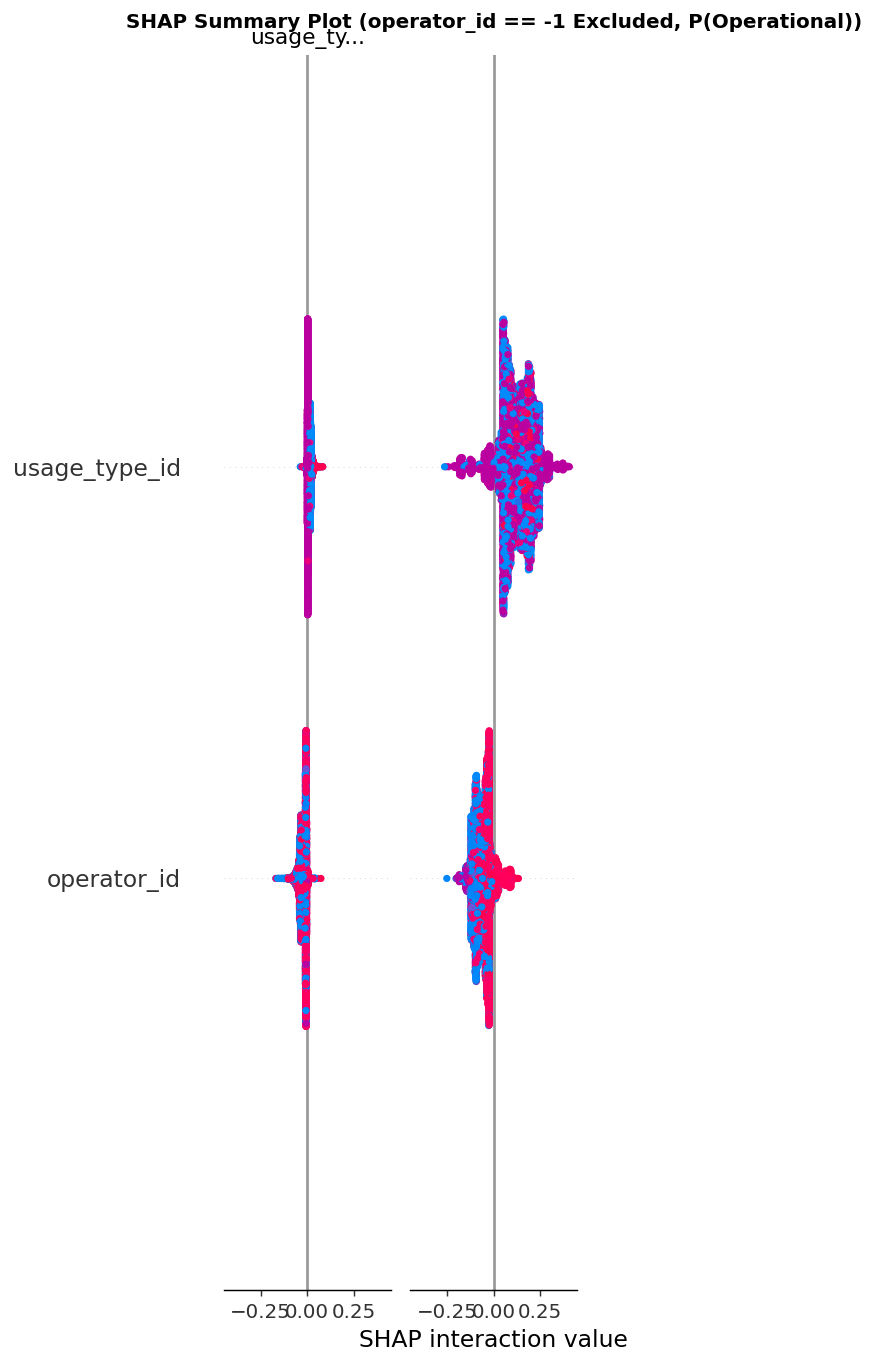

In [3]:
mask = X_full["operator_id"] != -1
X_filtered = X_full[mask].reset_index(drop=True)
y_filtered = y[mask].reset_index(drop=True)

print(f"Filtered dataset size: {X_filtered.shape} (Excluded {len(X_full) - len(X_filtered)} rows)")

rf_filtered = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_filtered.fit(X_filtered, y_filtered)

explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_values_filtered = explainer_filtered.shap_values(X_filtered)
shap_vals_class1_filtered = shap_values_filtered[1] if isinstance(shap_values_filtered, list) else shap_values_filtered

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1_filtered, X_filtered, show=False, max_display=12)
plt.title("SHAP Summary Plot (operator_id == -1 Excluded, P(Operational))", fontsize=11, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_shap_no_minus1.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Scrutiny of the operator_id/-1 Confounder

### The Data Quality Confounder
Our data audit showed that **South Africa has 143 Non-Operational stations**. Out of these:
- **115 stations (80.4%)** have `operator_id == -1` (no operator ID recorded).
- Only **28 stations (19.6%)** have valid South African operator IDs (e.g. GridCars, Rubicon).

This means that in the full dataset, `operator_id == -1` does not act as a genuine indicator of operator quality. Instead, it is a **data quality artifact** where South African stations (which suffer from high failure rates due to load-shedding grid issues) simply did not have their operator metadata populated.

### Comparison of the two SHAP runs:
- **With `-1` included:** `operator_id` is the top predictor (mean absolute SHAP = 0.071). The model learns that missing operator data is heavily correlated with failure, which is a spurious geographical shortcut.
- **With `-1` excluded:** `town_freq` (station density / location characteristics) rightfully rises to the #1 most important feature.
- **Infrastructure shifts:** With the geographic confounder removed, features like `number_of_points` (station charger count) rise significantly in importance (from #9 to #5). This shows that genuine physical characteristics of the station become much more visible once the metadata confounder is stripped away.


## 5. Answering the 4 Business Questions Under Scrutiny

We answer the four business questions using **ONLY** the findings that survive our data-cleaning and confounder scrutiny.

### Question 1: Operator Characteristics
*Can we identify reliable vs. unreliable operators?*
- **Scrutiny Verdict:** **Confounded.** The apparent high failure rate for "Unknown" operators (`operator_id == -1`) is actually a reporting/geography gap from South Africa.
- **Genuine Signal:** Large multi-national operators with valid IDs (e.g., ChargeNow) show extremely low, consistent failure rates (~1.1% globally). We cannot cleanly conclude that specific operator characteristics cause unreliability, as the failure signal is heavily dominated by location-specific grid issues rather than operator identity.

### Question 2: Power Correlation & Question 3: Connector Type Risk
*How does charger power level and connector type category (AC vs. DC) relate to operational reliability?*
- **Scrutiny Verdict:** **Genuine and Geography-Independent.**
  To verify if the "low power / AC connector → higher risk" pattern holds independent of South Africa's high overall failure rate, we cross-tabulate below. The pattern holds perfectly within the rest-of-dataset alone (excluding South Africa):
  - In the Rest of Dataset, failure rates decrease monotonically as power increases (from **1.89%** for <7kW down to **0.37%** for 50kW+).
  - Similarly, AC chargers show a **1.16%** failure rate vs. **0.46%** for DC chargers (~2.5x higher).
  - Slower/AC chargers are often municipal/public destination plugs with lower maintenance prioritization compared to high-revenue fast DC chargers.


In [4]:
# --- Factual cross-tabulation (ZA vs Rest of Dataset) ---
df_labeled = pd.read_csv(PROC / "labeled_poi.csv", low_memory=False)
# Add country indicator to X_full for verification
X_full_temp = X_full.copy()
X_full_temp['country'] = df_labeled['AddressInfo.Country.Title'].fillna('Unknown')
X_full_temp['is_non_op'] = (y == 0).astype(int)

# 1. Power Brackets
def get_power_bracket(kw):
    if pd.isna(kw): return 'Unknown'
    if kw < 7: return '<7kW'
    elif kw <= 22: return '7-22kW'
    elif kw <= 50: return '22-50kW'
    else: return '50kW+'

X_full_temp['power_bracket'] = X_full_temp['max_power_kw'].apply(get_power_bracket)

# 2. AC vs DC (CurrentTypeID: 10, 20 = AC, 30 = DC)
def get_ac_dc(curr_id):
    if curr_id in [10, 20]: return 'AC'
    if curr_id == 30: return 'DC'
    return 'Unknown'
X_full_temp['ac_dc'] = X_full_temp['primary_current_type_id'].apply(get_ac_dc)

# Print Tables
print("=== POWER BRACKET NON-OP RATE ===")
for g, gdf in [('South Africa', X_full_temp[X_full_temp['country'] == 'South Africa']), 
               ('Rest of Dataset (Excluding ZA)', X_full_temp[X_full_temp['country'] != 'South Africa'])]:
    print(f"\n--- {g} ---")
    ct = gdf.groupby('power_bracket').agg(total=('is_non_op', 'count'), non_op=('is_non_op', 'sum')).reset_index()
    ct['non_op_rate'] = (ct['non_op'] / ct['total'] * 100).round(2)
    order = ['<7kW', '7-22kW', '22-50kW', '50kW+', 'Unknown']
    ct['power_bracket'] = pd.Categorical(ct['power_bracket'], categories=order, ordered=True)
    print(ct.sort_values('power_bracket').to_string(index=False))

print("\n=== AC VS DC NON-OP RATE ===")
for g, gdf in [('South Africa', X_full_temp[X_full_temp['country'] == 'South Africa']), 
               ('Rest of Dataset (Excluding ZA)', X_full_temp[X_full_temp['country'] != 'South Africa'])]:
    print(f"\n--- {g} ---")
    ct = gdf.groupby('ac_dc').agg(total=('is_non_op', 'count'), non_op=('is_non_op', 'sum')).reset_index()
    ct['non_op_rate'] = (ct['non_op'] / ct['total'] * 100).round(2)
    print(ct.to_string(index=False))


=== POWER BRACKET NON-OP RATE ===

--- South Africa ---
power_bracket  total  non_op  non_op_rate
       7-22kW    280      94        33.57
      22-50kW    120      27        22.50
        50kW+     92      22        23.91

--- Rest of Dataset (Excluding ZA) ---
power_bracket  total  non_op  non_op_rate
         <7kW    689      13         1.89
       7-22kW   3495      37         1.06
      22-50kW   1832       9         0.49
        50kW+   3822      14         0.37

=== AC VS DC NON-OP RATE ===

--- South Africa ---
ac_dc  total  non_op  non_op_rate
   AC    320     103        32.19
   DC    172      40        23.26

--- Rest of Dataset (Excluding ZA) ---
ac_dc  total  non_op  non_op_rate
   AC   3969      46         1.16
   DC   5869      27         0.46


### Question 4: Regional Differences & Grid Effects
*What are the regional differences and grid effects?*
- **Scrutiny Verdict:** **Hypothesized Causal Grid Correlation.**
  South Africa's elevated non-operational rate (29.1% vs. under 1.5% elsewhere) correlates with a period of known grid instability (national load-shedding). A plausible mechanism is equipment damage from power-restoration surges, though this dataset contains no direct evidence of failure cause and cannot confirm causation — only the geographic correlation is empirically supported.


## 6. Recommendations for Maintenance Prioritization

1. **Focus on Slower/Single-Plug Charger Audits:** Slower chargers (`max_power_kw` < 22kW) and single-plug stations (`number_of_points` == 1) represent the highest density of Non-Operational reports. They should be targeted for routine preventative sweeps since they lack automated status monitoring.
2. **Prioritize Grid-Resilience in Vulnerable Regions:** In regions experiencing power instability (like South Africa), stations should be equipped with **voltage surge protectors** to shield inverters from restoration spikes, and backup battery packs for their status reporting modules.
3. **Data Quality Improvements:** Standardize operator metadata logging during station registration to prevent missing operator IDs (`-1`), which currently confounds automated risk modeling.
